In [1]:
import polars as pl

In [ ]:
#import the annotation table of the mgf used as input in the FASST search
annotation_table = pl.read_csv("/.../Carnitine_library_2025_testing_annotation_table.tsv", separator="\t", ignore_errors=True)


In [ ]:
#import matches after the raw_cosine calculation
matches = pl.read_csv("/.../matches_cosine_calculation_output.tsv", separator="\t",
                      ignore_errors=True)

#merge with annotation table
matches = matches.join(annotation_table, on="Scan", how="left")

#calculate deltas
matches = matches.with_columns(
    (pl.col("precursor_mz") - 162.1125).alias("delta")
)

matches = matches.with_columns(
    pl.col("delta").round(2).alias("delta_round")
)

#filter for only matches with cosine_raw >= 0.7
matches = matches.filter(matches["cosine_raw"] >= 0.7)



In [4]:
#create a filepath column using polars expressions
matches = matches.with_columns(
	(
		pl.col("USI").str.split(":").list.get(1)
	).alias("dataset")
)

matches = matches.with_columns(
	(
		pl.col("dataset") + "/" + pl.col("USI").str.split(":").list.get(2).str.split("/").list.get(-1)
	).alias("filepath")
)

#remove the .mzML or .mzXML file ending from the filepath column
matches = matches.with_columns(
	pl.col('filepath').str.replace_all(r".mzML|.mzXML", "").alias('filepath')
)

In [5]:
#now let's get the information of how many spectra, from how many files, and from how many different datasets
num_spectra = len(matches['USI'].unique())
num_files = len(matches['filepath'].unique())
num_datasets = len(matches['dataset'].unique())
print(f"Number of spectra: {num_spectra}")
print(f"Number of files: {num_files}")
print(f"Number of datasets: {num_datasets}")

Number of spectra: 3872050
Number of files: 220793
Number of datasets: 1977


In [ ]:
#import ReDU table
df_redu = pl.read_csv("/.../all_sampleinformation_Sep30_2025.tsv", separator="\t",
                      ignore_errors=True)

# 1. remove "f." from filename
df_redu = df_redu.with_columns(
    pl.col("filename").str.replace("f.", "").alias("filename")
)

# 2. keep only last part after "/"
df_redu = df_redu.with_columns(
    pl.col("filename").str.split("/").list.get(-1).alias("filename_2")
)

# 3. remove extensions
df_redu = df_redu.with_columns(
    pl.col("filename_2").str.replace(r"\.mzML|\.mzXML", "").alias("filename_2")
)

# 4. create filepath
df_redu = df_redu.with_columns(
    (pl.col("ATTRIBUTE_DatasetAccession").cast(str) + "/" + pl.col("filename_2")).alias("filepath")
)

#merge the two dataframes on the filepath column
merged_redu = matches.join(df_redu, on="filepath", how="inner")


In [7]:
#Now let's split the human-related and the rodent-related datasets 

#Humans
df_humans = merged_redu.filter(pl.col('NCBITaxonomy') == '9606|Homo sapiens')

#Rodents
list_rattus_mus = ['10088|Mus','10090|Mus musculus','10105|Mus minutoides','10114|Rattus','10116|Rattus norvegicus']
df_rodents = merged_redu.filter(pl.col('NCBITaxonomy').is_in(list_rattus_mus))


In [ ]:
df_humans.write_csv('/.../matches_ReDU_humans_cos07.tsv', separator='\t')
df_rodents.write_csv('/.../matches_ReDU_rodents_cos07.tsv', separator='\t')

In [ ]:
# select only needed columns
df_humans = df_humans.select(["USI", "delta_round", "UBERONBodyPartName"])

# groupby and aggregate
humans_counts = (
    df_humans.group_by("UBERONBodyPartName")
    .agg([
        pl.col("USI").n_unique().alias("n_USIs"),
        pl.col("delta_round").n_unique().alias("n_deltas"),
    ])
)

# select only needed columns
df_rodents = df_rodents.select(["USI", "delta_round", "UBERONBodyPartName"])

# groupby and aggregate
rodents_counts = (
    df_rodents.group_by("UBERONBodyPartName")
    .agg([
        pl.col("USI").n_unique().alias("n_USIs"),
        pl.col("delta_round").n_unique().alias("n_deltas"),
    ])
)

# humans_counts.write_csv('/.../body_part_distribution_humans_cos07.tsv', separator='\t')
# rodents_counts.write_csv('/.../body_part_distribution_rodents_cos07.tsv', separator='\t')

# Bubble plot - Fig 2a,b

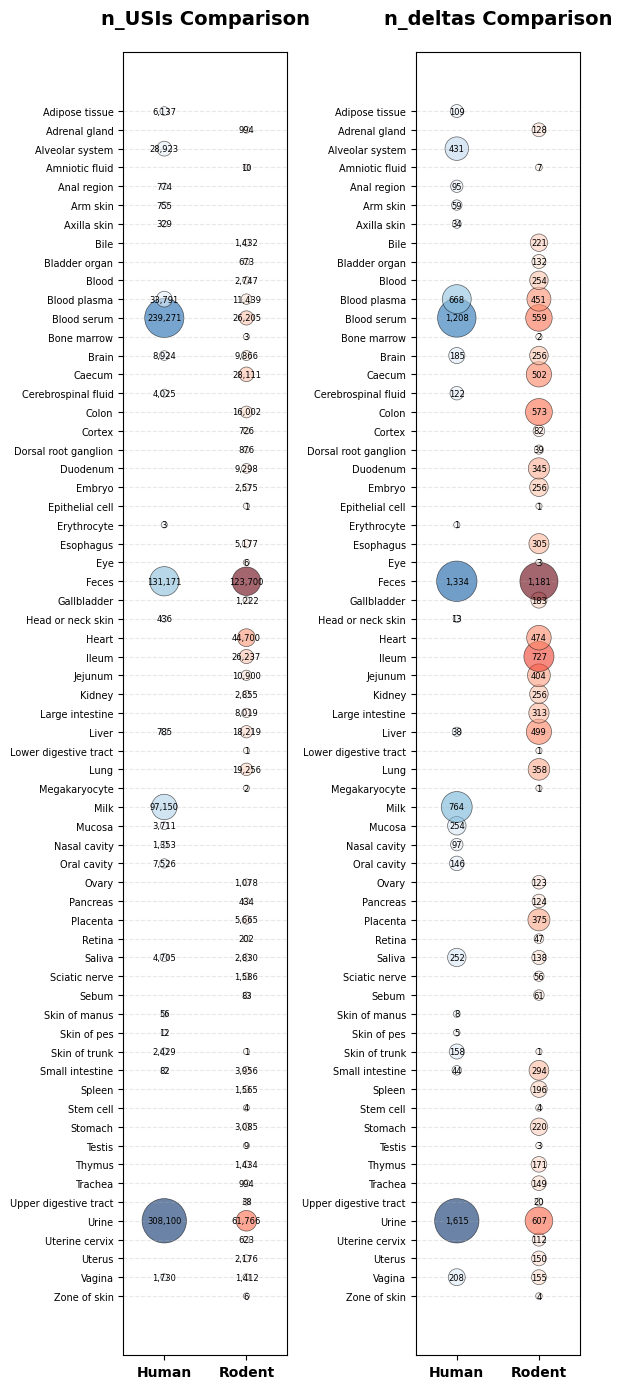

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read both datasets
df_humans = pd.read_csv('/.../body_part_distribution_humans_cos07.tsv', sep='\t')
df_rodents = pd.read_csv('/.../body_part_distribution_rodents_cos07.tsv', sep='\t')

# Remove 'missing value' rows
df_humans = df_humans[df_humans['UBERONBodyPartName'] != 'missing value']
df_rodents = df_rodents[df_rodents['UBERONBodyPartName'] != 'missing value']

# Get all unique body parts from both datasets
all_body_parts = set(df_humans['UBERONBodyPartName'].tolist() + 
                     df_rodents['UBERONBodyPartName'].tolist())

# Sort body parts alphabetically
all_body_parts = sorted(list(all_body_parts))

# Create a combined dataframe with all body parts
data = []
for bp in all_body_parts:
    human_row = df_humans[df_humans['UBERONBodyPartName'] == bp]
    rodent_row = df_rodents[df_rodents['UBERONBodyPartName'] == bp]
    
    data.append({
        'body_part': bp,
        'human_usis': human_row['n_USIs'].values[0] if len(human_row) > 0 else 0,
        'human_deltas': human_row['n_deltas'].values[0] if len(human_row) > 0 else 0,
        'rodent_usis': rodent_row['n_USIs'].values[0] if len(rodent_row) > 0 else 0,
        'rodent_deltas': rodent_row['n_deltas'].values[0] if len(rodent_row) > 0 else 0
    })

df = pd.DataFrame(data)

# Prepare data (reverse order so top of list appears at top of plot)
body_parts = df['body_part'].values[::-1]
# Capitalize first letter of each body part
body_parts = [bp.capitalize() for bp in body_parts]
df = df.iloc[::-1].reset_index(drop=True)
y_positions = np.arange(len(body_parts))

# Create two separate plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 14))

# --- PLOT 1: USIs Comparison ---
max_usis = max(df['human_usis'].max(), df['rodent_usis'].max())
size_scale = 1000
min_size = 20  # Minimum bubble size
human_usis_sizes = np.where(df['human_usis'] > 0, min_size + (df['human_usis'] / max_usis) * size_scale, 0)
rodent_usis_sizes = np.where(df['rodent_usis'] > 0, min_size + (df['rodent_usis'] / max_usis) * size_scale, 0)

# Plot bubbles for USIs
ax1.scatter([0] * len(body_parts), y_positions, s=human_usis_sizes, 
           c=df['human_usis'], cmap='Blues', alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.scatter([1] * len(body_parts), y_positions, s=rodent_usis_sizes, 
           c=df['rodent_usis'], cmap='Reds', alpha=0.6, edgecolors='black', linewidth=0.5)

# Add text labels inside bubbles for USIs with comma separator
for i, (y_pos, h_val, r_val) in enumerate(zip(y_positions, df['human_usis'], df['rodent_usis'])):
    if h_val > 0:
        ax1.text(0, y_pos, f'{int(h_val):,}', ha='center', va='center', 
                fontsize=6, color='black')
    if r_val > 0:
        ax1.text(1, y_pos, f'{int(r_val):,}', ha='center', va='center', 
                fontsize=6, color='black')

# Labels for plot 1
ax1.set_yticks(y_positions)
ax1.set_yticklabels(body_parts, fontsize=7)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Human', 'Rodent'], fontsize=10, fontweight='bold')
ax1.set_title('n_USIs Comparison', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(-0.5, 1.5)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# --- PLOT 2: Deltas Comparison ---
max_deltas = max(df['human_deltas'].max(), df['rodent_deltas'].max())
human_deltas_sizes = np.where(df['human_deltas'] > 0, min_size + (df['human_deltas'] / max_deltas) * size_scale, 0)
rodent_deltas_sizes = np.where(df['rodent_deltas'] > 0, min_size + (df['rodent_deltas'] / max_deltas) * size_scale, 0)

# Plot bubbles for deltas
ax2.scatter([0] * len(body_parts), y_positions, s=human_deltas_sizes, 
           c=df['human_deltas'], cmap='Blues', alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.scatter([1] * len(body_parts), y_positions, s=rodent_deltas_sizes, 
           c=df['rodent_deltas'], cmap='Reds', alpha=0.6, edgecolors='black', linewidth=0.5)

# Add text labels inside bubbles for deltas with comma separator
for i, (y_pos, h_val, r_val) in enumerate(zip(y_positions, df['human_deltas'], df['rodent_deltas'])):
    if h_val > 0:
        ax2.text(0, y_pos, f'{int(h_val):,}', ha='center', va='center', 
                fontsize=6, color='black')
    if r_val > 0:
        ax2.text(1, y_pos, f'{int(r_val):,}', ha='center', va='center', 
                fontsize=6, color='black')

# Labels for plot 2
ax2.set_yticks(y_positions)
ax2.set_yticklabels(body_parts, fontsize=7)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Human', 'Rodent'], fontsize=10, fontweight='bold')
ax2.set_title('n_deltas Comparison', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlim(-0.5, 1.5)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('/.../bubble_plot_USIs_deltas_alphabetical.pdf')
plt.show()

# Upset plot - Humans - Figure 2c

In [12]:
import polars as pl
from upsetplot import UpSet
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

In [ ]:
#import dataframe
df = pl.read_csv('/.../matches_ReDU_humans_cos07.tsv', separator='\t', ignore_errors=True)

#simplify body part names by replacing specific terms with more general ones
df = df.with_columns([
	pl.col('UBERONBodyPartName').str.replace('skin of trunk', 'skin')
							   .str.replace('skin of pes', 'skin')
							   .str.replace('head or neck skin', 'skin')
							   .str.replace('axilla skin', 'skin')
							   .str.replace('skin of manus', 'skin')
							   .str.replace('arm skin', 'skin')
                               .str.replace('skin of leg', 'skin')
							   .str.replace('zone of skin', 'skin')	
							   .str.replace('blood plasma', 'blood')
							   .str.replace('blood serum', 'blood')
							   .alias('UBERONBodyPartName')
])

df = df.filter(pl.col('UBERONBodyPartName') != 'missing value')

In [14]:
# create a dataframw tieh list of deltas per body part
unique_by_part = (
    df.select(['UBERONBodyPartName', 'delta_round'])
    .group_by('UBERONBodyPartName')
    .agg(pl.col("delta_round").drop_nulls().unique().sort().alias("delta_list"))
)

# Convert to a Python dict: {body_part: [list of deltas]}
bodypart_to_deltas = {
    row["UBERONBodyPartName"]: row["delta_list"]
    for row in unique_by_part.iter_rows(named=True)
}


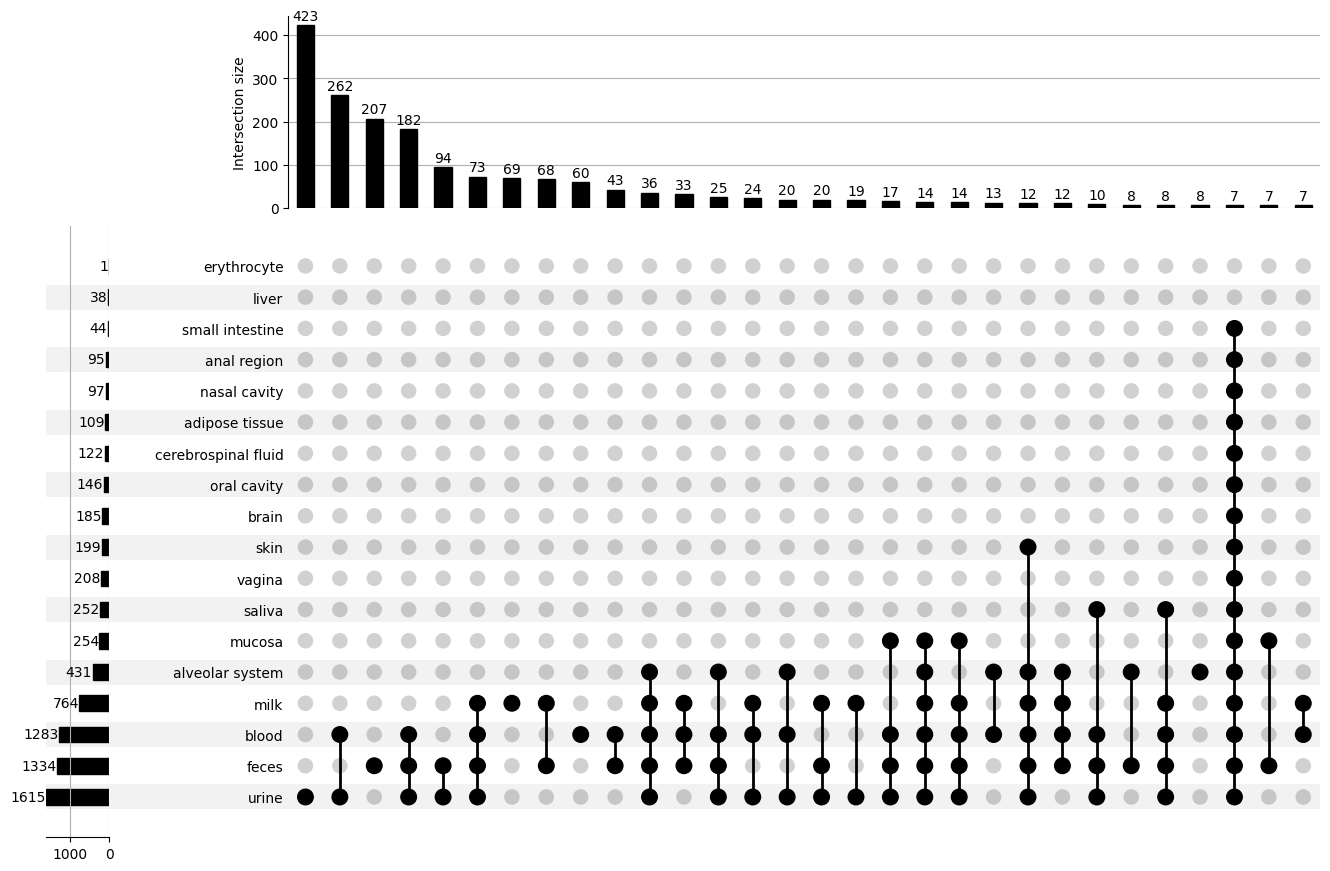

In [ ]:
upset_data = from_contents(bodypart_to_deltas)

upset = UpSet(upset_data, 
              subset_size='count',
              show_counts=True,
              sort_by='cardinality',
              sort_categories_by='cardinality',
              max_subset_rank=30)

#add max_subset_rank=30 to limit to top 30 groups

upset.plot()
import matplotlib.pyplot as plt
# plt.gcf().savefig('/.../upset_plot_humans_Top30Groups.pdf')

# Upset plot - Rodents - Figure 2d

In [1]:
import polars as pl
from upsetplot import UpSet
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

In [ ]:
#import dataframe
df = pl.read_csv('/.../matches_ReDU_rodents_cos07.tsv', separator='\t', ignore_errors=True)

#simplify body part names by replacing specific terms with more general ones
df = df.with_columns([
	pl.col('UBERONBodyPartName').str.replace('skin of trunk', 'skin')
							   .str.replace('skin of pes', 'skin')
							   .str.replace('head or neck skin', 'skin')
							   .str.replace('axilla skin', 'skin')
							   .str.replace('skin of manus', 'skin')
							   .str.replace('arm skin', 'skin')
                               .str.replace('skin of leg', 'skin')
							   .str.replace('zone of skin', 'skin')	
							   .str.replace('blood plasma', 'blood')
							   .str.replace('blood serum', 'blood')
							   .alias('UBERONBodyPartName')
])

df = df.filter(pl.col('UBERONBodyPartName') != 'missing value')

In [3]:
# create a dataframw tieh list of deltas per body part
unique_by_part = (
    df.select(['UBERONBodyPartName', 'delta_round'])
    .group_by('UBERONBodyPartName')
    .agg(pl.col("delta_round").drop_nulls().unique().sort().alias("delta_list"))
)

# Convert to a Python dict: {body_part: [list of deltas]}
bodypart_to_deltas = {
    row["UBERONBodyPartName"]: row["delta_list"]
    for row in unique_by_part.iter_rows(named=True)
}


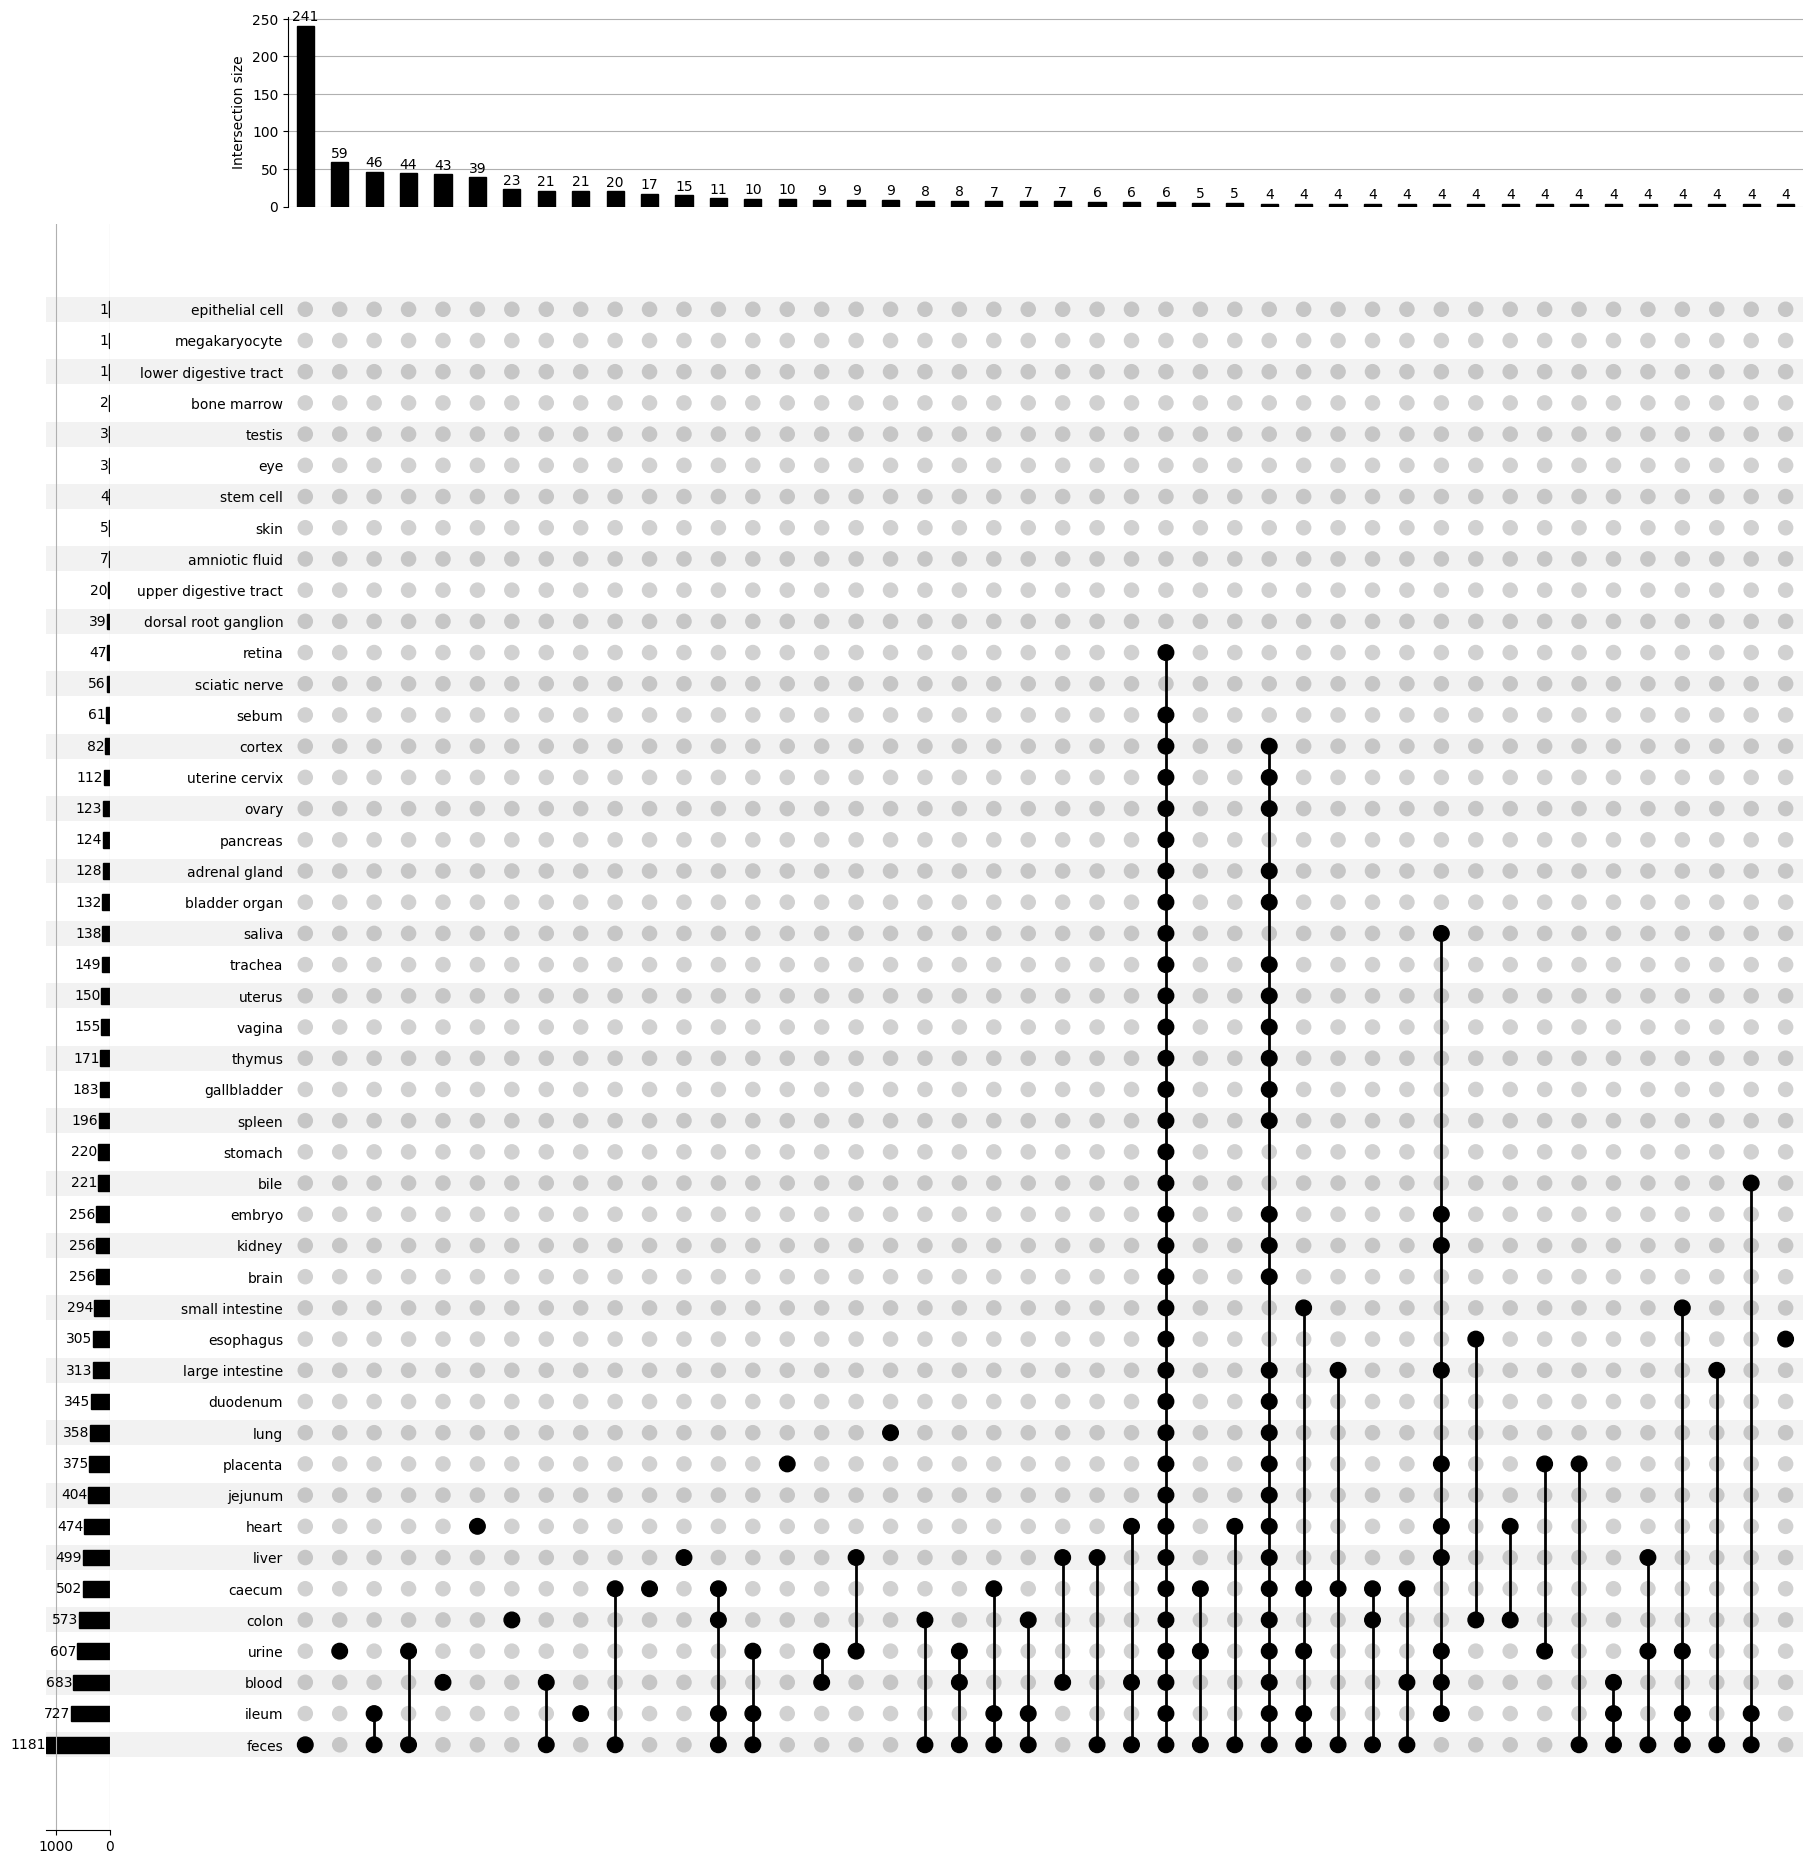

In [ ]:
upset_data = from_contents(bodypart_to_deltas)

upset = UpSet(upset_data, 
              subset_size='count',
              show_counts=True,
              sort_by='cardinality',
              sort_categories_by='cardinality',
              max_subset_rank=30)

#add max_subset_rank=30 to limit to top 30 groups

upset.plot()
import matplotlib.pyplot as plt
# plt.gcf().savefig('/.../upset_plot_rodents_Top30Groups.pdf')